In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc


### Data Loading and Preprocessing

We load the training and test datasets from CSV files. The training data consists of two separate files, which are combined into a single dataset.

We remove observations with label `0`, as they represent uncertain or unlabeled data. Additionally, we drop unnecessary columns such as `image_id`, `x`, and `y`, since they are not used as input features for the model.

In [3]:
import pandas as pd

df_train_1 = pd.read_csv("../data/O012791.csv")
df_train_2 = pd.read_csv("../data/O013257.csv")

df_train = pd.concat([df_train_1, df_train_2], ignore_index=True)


df_test = pd.read_csv("../data/O013490.csv")

df_train_filtered = df_train[df_train['expert_label'] != 0]


df_train = df_train.drop(columns=["image_id", "y", "x"], errors="ignore")
df_test = df_test.drop(columns=["image_id", "y", "x"], errors="ignore")

### CART Model with Baseline Features

In this step, we train a Decision Tree (CART) model using only the original set of features:  
`NDAI`, `SD`, `CORR`, `DF`, `CF`, `BF`, `AF`, and `AN`.

The dataset is filtered to exclude unlabeled observations. A shallow decision tree is used to avoid overfitting and to capture the main structure of the data.

Finally, predictions are generated on the test set.

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.99      0.91      0.95     42830
         1.0       0.91      0.99      0.95     39253

    accuracy                           0.95     82083
   macro avg       0.95      0.95      0.95     82083
weighted avg       0.95      0.95      0.95     82083



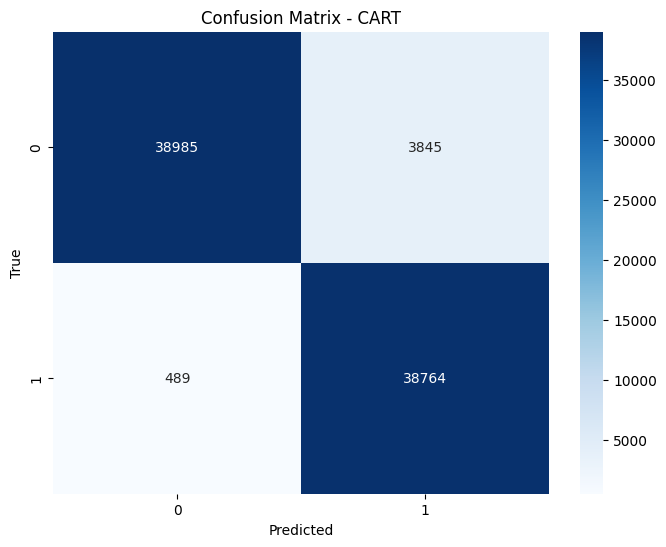

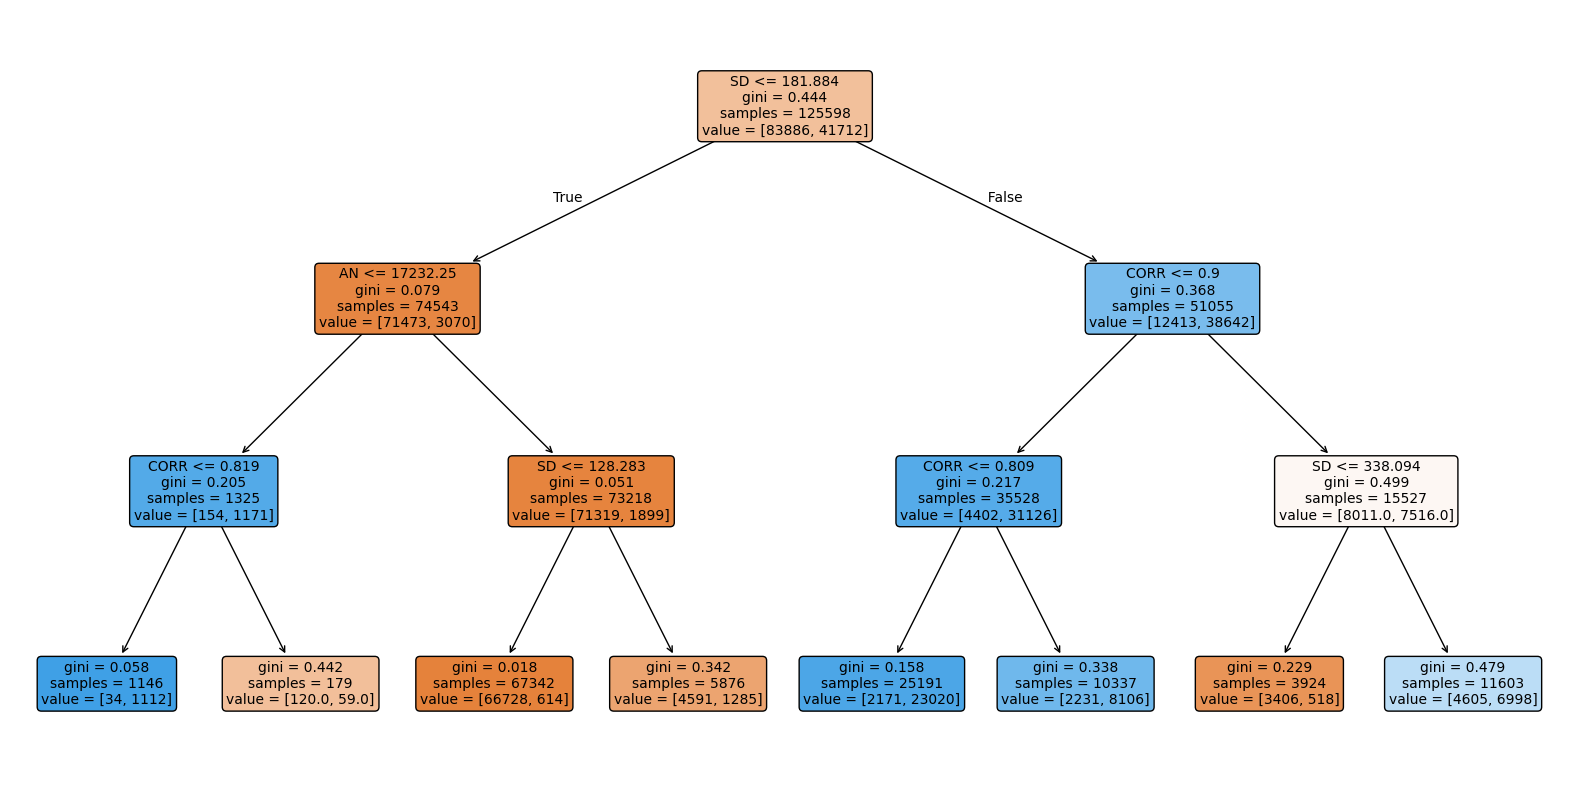

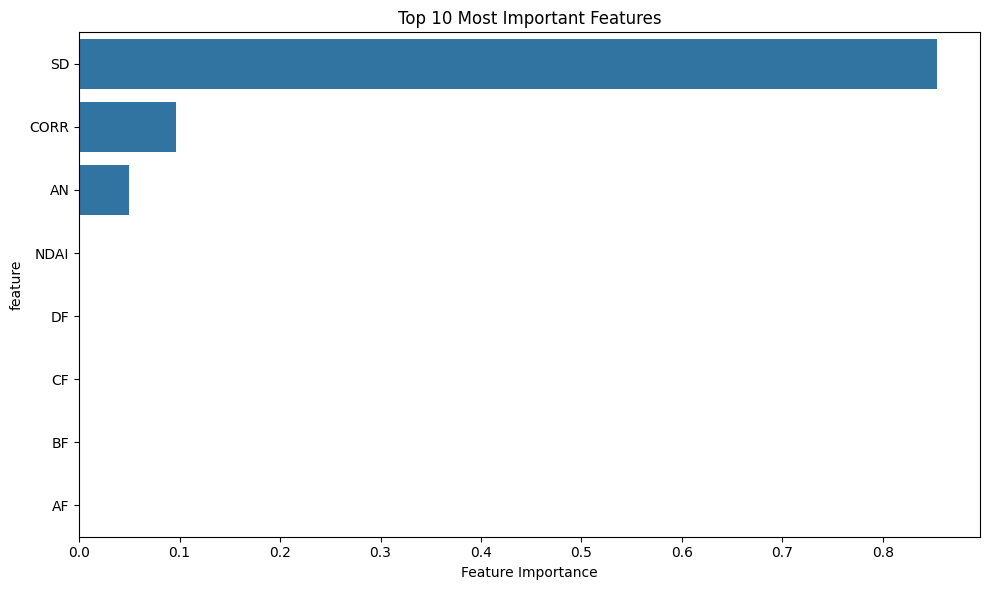

In [4]:
# Cart with old features
df_train_filtered = df_train[df_train['expert_label'] != 0]
df_test_filtered = df_test[df_test['expert_label'] != 0]

X_train = df_train_filtered[["NDAI", "SD", "CORR", "DF", "CF", "BF", "AF", "AN"]]
y_train = df_train_filtered["expert_label"]

X_test = df_test_filtered[["NDAI", "SD", "CORR", "DF", "CF", "BF", "AF", "AN"]]
y_test = df_test_filtered["expert_label"]

cart_model = DecisionTreeClassifier(random_state=42, max_depth=3)
cart_model.fit(X_train, y_train)

y_pred = cart_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm_small = cm

plt.figure(figsize=(8, 6))
plt.title("Confusion Matrix - CART")
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(cart_model, feature_names=X_train.columns, filled=True, rounded=True, fontsize=10)

plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cart_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Plot top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Most Important Features')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

### CART Model with Baseline Features

In this step, we train a Decision Tree (CART) model using only the original set of features:  
`NDAI`, `SD`, `CORR`, `DF`, `CF`, `BF`, `AF`, and `AN`.

The dataset is filtered to exclude unlabeled observations. A shallow decision tree is used to avoid overfitting and to capture the main structure of the data.

Finally, predictions are generated on the test set.

Classification Report:
              precision    recall  f1-score   support

        -1.0       1.00      0.98      0.99     42830
         1.0       0.98      1.00      0.99     39253

    accuracy                           0.99     82083
   macro avg       0.99      0.99      0.99     82083
weighted avg       0.99      0.99      0.99     82083



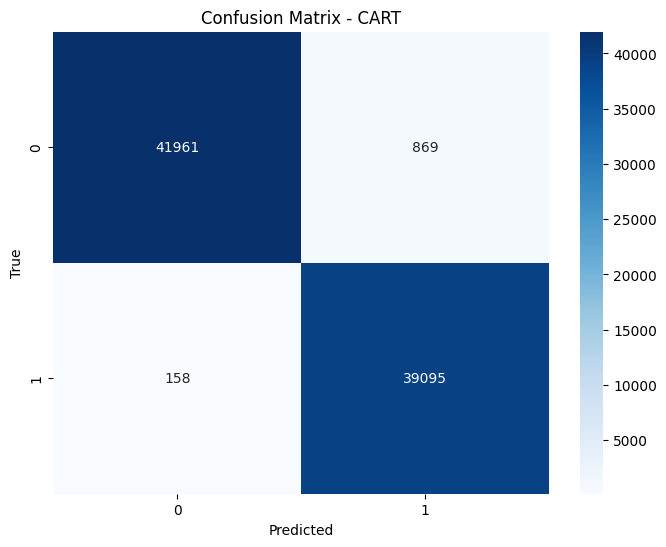

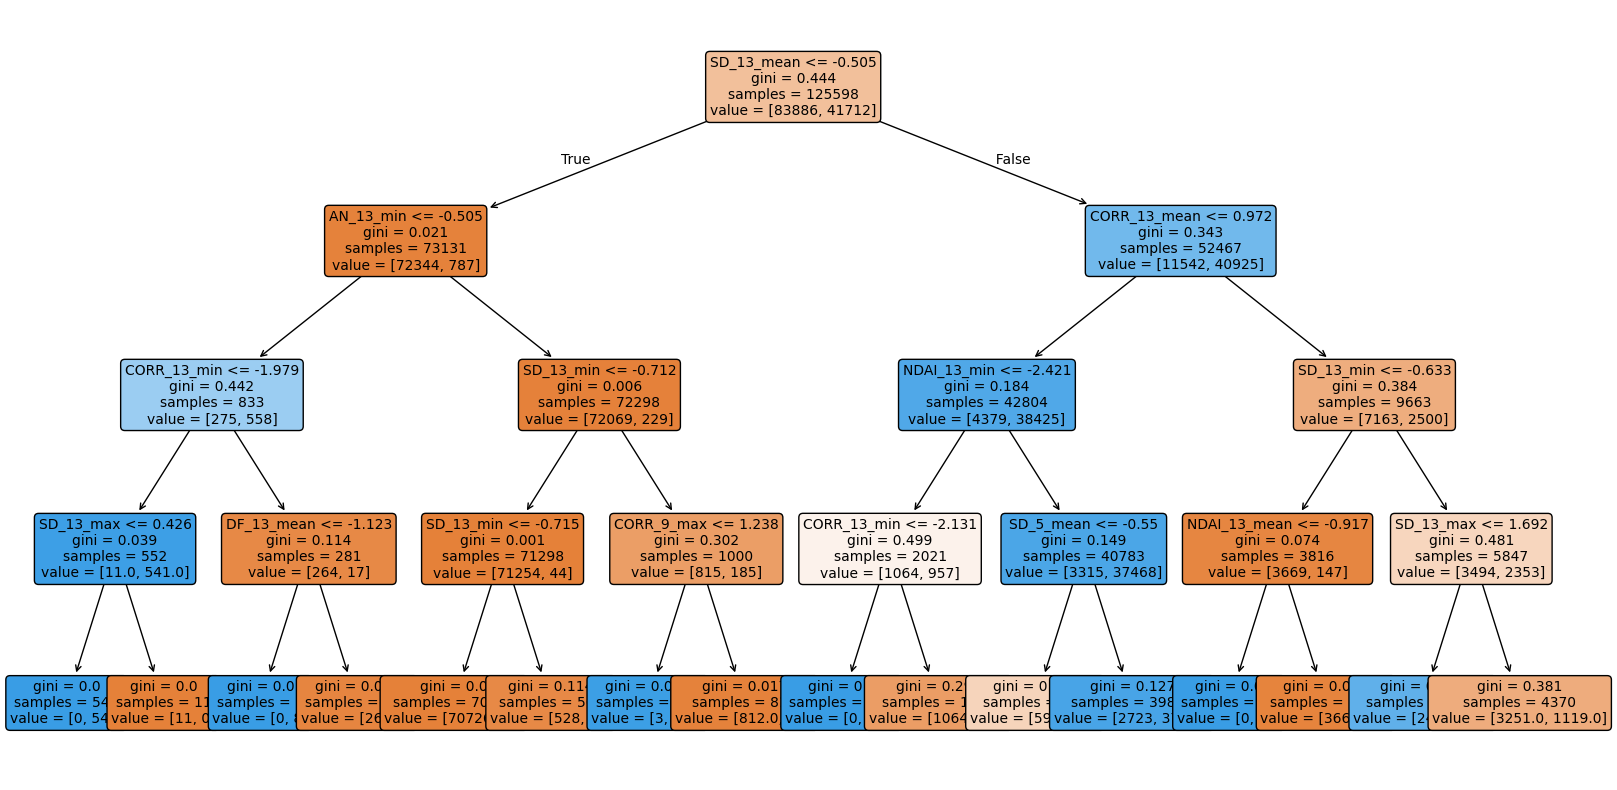

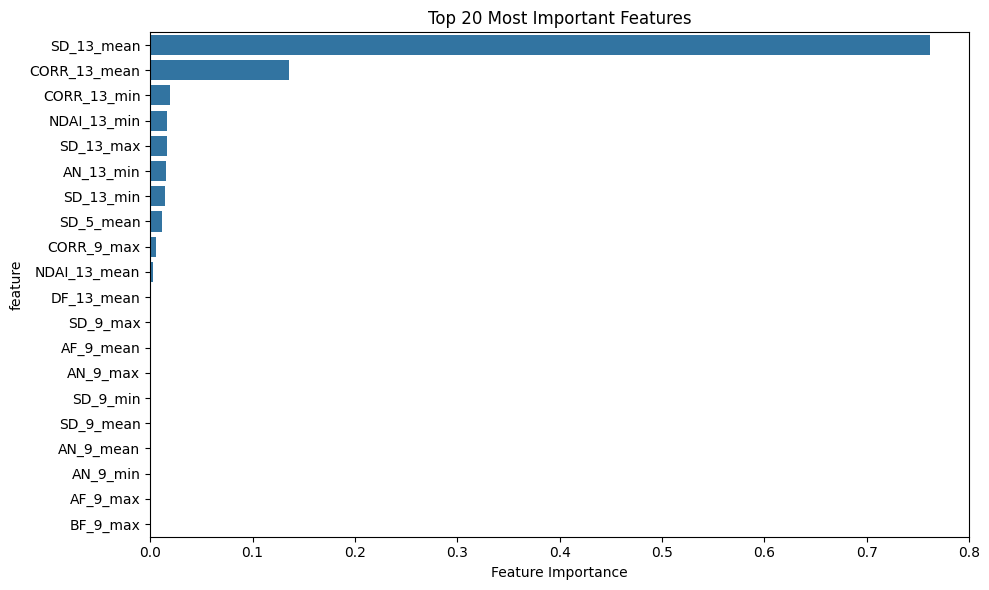

In [5]:
# Cart with all new features
df_train_filtered = df_train[df_train['expert_label'] != 0]
df_test_filtered = df_test[df_test['expert_label'] != 0]

X_train = df_train_filtered.drop(['expert_label'], axis = 1)
y_train = df_train_filtered["expert_label"]

X_test = df_test_filtered.drop(['expert_label'], axis = 1)
y_test = df_test_filtered["expert_label"]

cart_model = DecisionTreeClassifier(random_state=42, max_depth=4)
cart_model.fit(X_train, y_train)

y_pred = cart_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.title("Confusion Matrix - CART")
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(cart_model, feature_names=X_train.columns, filled=True, rounded=True, fontsize=10)
#plt.title("CART Decision Tree using Selected Columns")
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cart_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Plot top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(20), x='importance', y='feature')
plt.title('Top 20 Most Important Features')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()